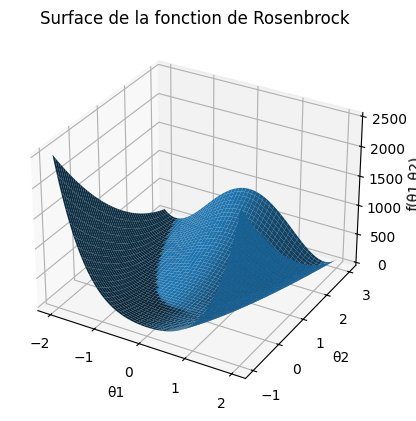

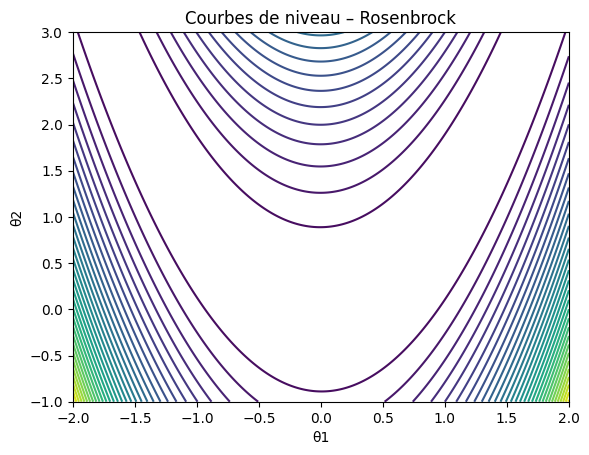

Condition initiale      : [-1.2  1. ]
Solution trouvée        : [1.00002202 1.00004222]
Valeur minimale f       : 8.177661197416674e-10
Nombre d'itérations     : 85
Nombre eval. fonction   : 159
Convergence             : True
epsilon (tolérance)     : 0.0001
max_it                  : 1000
----------------------------------------
Condition initiale      : [0. 0.]
Solution trouvée        : [1.00000439 1.00001064]
Valeur minimale f       : 3.6861769151759075e-10
Nombre d'itérations     : 79
Nombre eval. fonction   : 146
Convergence             : True
epsilon (tolérance)     : 0.0001
max_it                  : 1000
----------------------------------------
Condition initiale      : [2. 2.]
Solution trouvée        : [0.99998292 0.99996512]
Valeur minimale f       : 3.4239552925089766e-10
Nombre d'itérations     : 62
Nombre eval. fonction   : 119
Convergence             : True
epsilon (tolérance)     : 0.0001
max_it                  : 1000
----------------------------------------
Condition ini

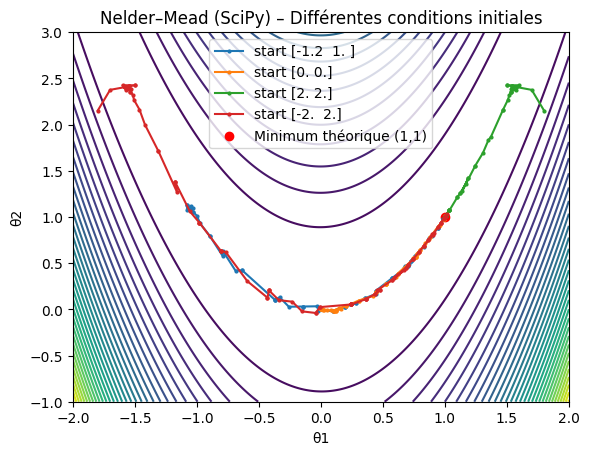

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar
import time
from math import factorial
from scipy.special import gammaln
from scipy.stats import norm
from scipy.optimize import least_squares

# =============================
# Fonction de Rosenbrock
# =============================
def rosenbrock(theta):
    x, y = theta
    return 100*(y - x**2)**2 + (1 - x)**2

# =============================
# Grille pour visualisation
# =============================
x = np.linspace(-2, 2, 300)
y = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x, y)
Z = 100*(Y - X**2)**2 + (1 - X)**2

# =============================
# 1) Surface 3D
# =============================
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z)
ax.set_xlabel("θ1")
ax.set_ylabel("θ2")
ax.set_zlabel("f(θ1,θ2)")
ax.set_title("Surface de la fonction de Rosenbrock")
plt.show()

# =============================
# 2) Courbes de niveau
# =============================
plt.figure()
plt.contour(X, Y, Z, levels=40)
plt.xlabel("θ1")
plt.ylabel("θ2")
plt.title("Courbes de niveau – Rosenbrock")
plt.show()

# =============================
# Paramètres demandés
# =============================
epsilon = 1e-4
max_it = 1000

# =============================
# Conditions initiales
# =============================
initial_points = [
    np.array([-1.2, 1.0]),
    np.array([0.0, 0.0]),
    np.array([2.0, 2.0]),
    np.array([-2.0, 2.0])
]

# =============================
# 3) Nelder–Mead + trajectoires
# =============================
plt.figure()
plt.contour(X, Y, Z, levels=40)

for theta0 in initial_points:
    path = []

    def callback(xk):
        path.append(xk.copy())

    res = minimize(
        rosenbrock,
        theta0,
        method="Nelder-Mead",
        callback=callback,
        options={
            "xatol": epsilon,
            "maxiter": max_it,
            "disp": False
        }
    )

    path = np.array(path)

    # ---------- AFFICHAGE DES INFOS DEMANDÉES ----------
    print("Condition initiale      :", theta0)
    print("Solution trouvée        :", res.x)
    print("Valeur minimale f       :", res.fun)
    print("Nombre d'itérations     :", res.nit)
    print("Nombre eval. fonction   :", res.nfev)
    print("Convergence             :", res.success)
    print("epsilon (tolérance)     :", epsilon)
    print("max_it                  :", max_it)
    print("----------------------------------------")

    plt.plot(path[:,0], path[:,1], 'o-', markersize=2,
             label=f"start {theta0}")

plt.scatter(1, 1, color="red", label="Minimum théorique (1,1)")
plt.xlabel("θ1")
plt.ylabel("θ2")
plt.title("Nelder–Mead (SciPy) – Différentes conditions initiales")
plt.legend()
plt.show()

In [ ]:
#Donnés pour R , mais on fera en python :
# 1) mettre reltol à 10^-12, recuperer le code en sortie de l'algorithme
#s'il y' a convergence , on verifie que c'est vers (1,1)( On calcule une distnace euclidienne, inf à10^-2)
#on fait ça pour 1000 Cond initiale uniformement repareties sur [-2,2]*[-2,2]

#Pourcentage de convergence vers (1,1)

#2) faire varier reltol de 10^-12 à 10^-2 et representer l'évolution de la probabilité de convergence vers (1,1)

reltol = 1e-12
Probabilité de convergence vers (1,1) : 1.0

reltol = 1.0e-12  -->  probabilité = 1.0000
reltol = 1.0e-11  -->  probabilité = 1.0000
reltol = 1.0e-10  -->  probabilité = 1.0000
reltol = 1.0e-09  -->  probabilité = 1.0000
reltol = 1.0e-08  -->  probabilité = 1.0000
reltol = 1.0e-07  -->  probabilité = 1.0000
reltol = 1.0e-06  -->  probabilité = 1.0000
reltol = 1.0e-05  -->  probabilité = 1.0000
reltol = 1.0e-04  -->  probabilité = 1.0000
reltol = 1.0e-03  -->  probabilité = 0.9980
reltol = 1.0e-02  -->  probabilité = 0.7210


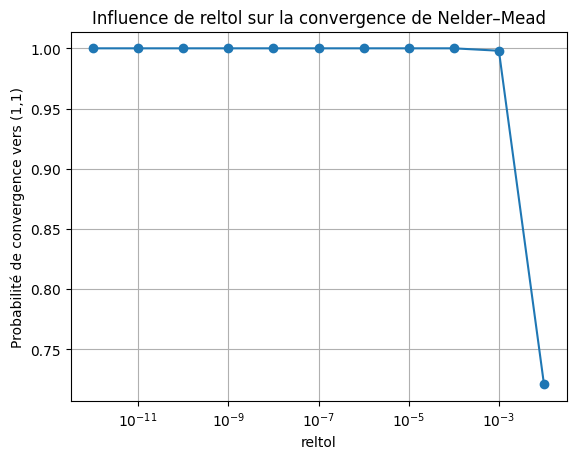

In [3]:
# ============================================================
# Paramètres globaux
# ============================================================
N = 1000                    # nombre de conditions initiales
domain_min, domain_max = -2, 2
target = np.array([1.0, 1.0])
dist_tol = 1e-2             # tolérance pour vérifier convergence vers (1,1)


# ============================================================
# Génération des conditions initiales uniformes
# ============================================================
initial_points = np.random.uniform(
    domain_min, domain_max, size=(N, 2)
)


# ============================================================
# FONCTION QUI CALCULE LA PROBABILITÉ DE CONVERGENCE
# POUR UNE VALEUR DE reltol DONNÉE
# ============================================================
def convergence_probability(reltol):

    converged_to_target = 0

    for theta0 in initial_points:

        res = minimize(
            rosenbrock,
            theta0,
            method="Nelder-Mead",
            options={
                "xatol": reltol,
                "fatol": reltol,
                "maxiter": 5000,
                "disp": False
            }
        )

        # Vérification du code de convergence
        if res.success:
            # Distance euclidienne au point (1,1)
            distance = np.linalg.norm(res.x - target)

            if distance < dist_tol:
                converged_to_target += 1

    return converged_to_target / N


# ============================================================
# 1) reltol = 10^-12
# ============================================================
reltol_fixed = 1e-12
prob_fixed = convergence_probability(reltol_fixed)

print("==========================================")
print("reltol =", reltol_fixed)
print("Probabilité de convergence vers (1,1) :", prob_fixed)
print("==========================================\n")


# ============================================================
# 2) FAIRE VARIER reltol DE 10^-12 À 10^-2
# ============================================================
reltol_values = np.logspace(-12, -2, 11)
probabilities = []

for rt in reltol_values:
    prob = convergence_probability(rt)
    probabilities.append(prob)
    print(f"reltol = {rt:.1e}  -->  probabilité = {prob:.4f}")


# ============================================================
# REPRÉSENTATION GRAPHIQUE
# ============================================================
plt.figure()
plt.semilogx(reltol_values, probabilities, marker='o')
plt.xlabel("reltol")
plt.ylabel("Probabilité de convergence vers (1,1)")
plt.title("Influence de reltol sur la convergence de Nelder–Mead")
plt.grid(True)
plt.show()


========== EXERCICE 2 ==========

Résumé des performances
----------------------------------------------------------------------
Nelder-Mead          | taux succès = 100.00% | moy = 200.9 | méd = 201.5 | min = 132.0 | max = 277.0
Plus grande pente    | taux succès = 82.00% | moy = 50247.1 | méd = 37971.5 | min = 1645.0 | max = 99387.0


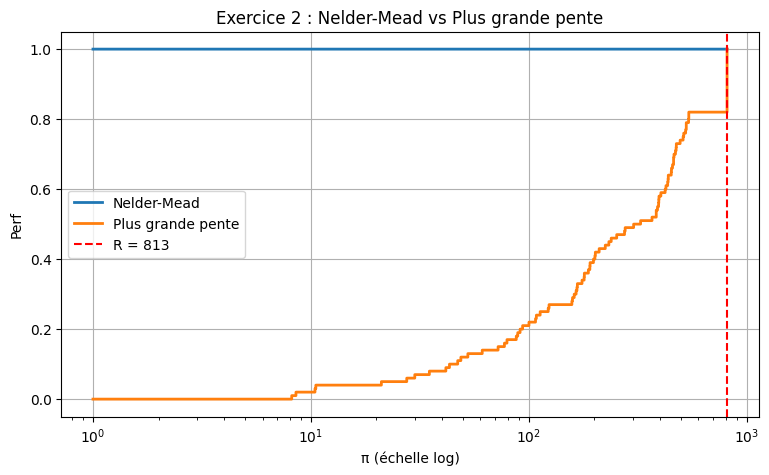


========== EXERCICE 3 ==========

Résumé des performances
----------------------------------------------------------------------
Nelder-Mead          | taux succès = 100.00% | moy = 200.9 | méd = 201.5 | min = 132.0 | max = 277.0
Plus grande pente    | taux succès = 82.00% | moy = 50247.1 | méd = 37971.5 | min = 1645.0 | max = 99387.0
Newton-Raphson       | taux succès = 100.00% | moy = 314.7 | méd = 297.0 | min = 108.0 | max = 577.0


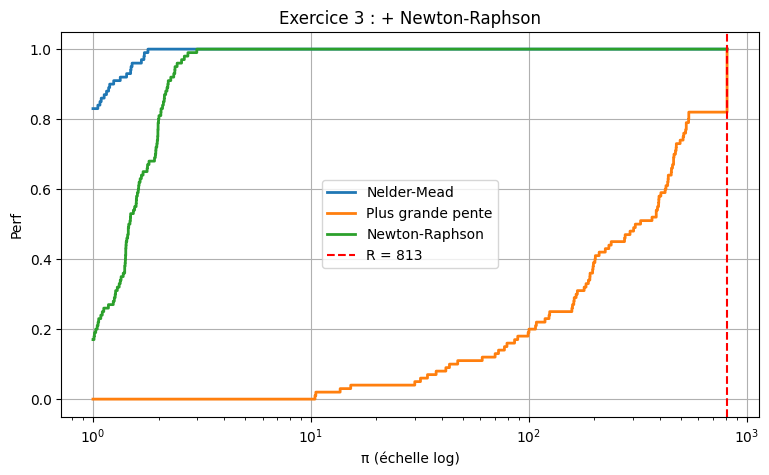


========== EXERCICE 4 ==========

Résumé des performances
----------------------------------------------------------------------
Nelder-Mead          | taux succès = 100.00% | moy = 200.9 | méd = 201.5 | min = 132.0 | max = 277.0
Plus grande pente    | taux succès = 82.00% | moy = 50247.1 | méd = 37971.5 | min = 1645.0 | max = 99387.0
Newton-Raphson       | taux succès = 100.00% | moy = 314.7 | méd = 297.0 | min = 108.0 | max = 577.0
BFGS                 | taux succès = 77.00% | moy = 108.7 | méd = 102.0 | min = 48.0 | max = 216.0


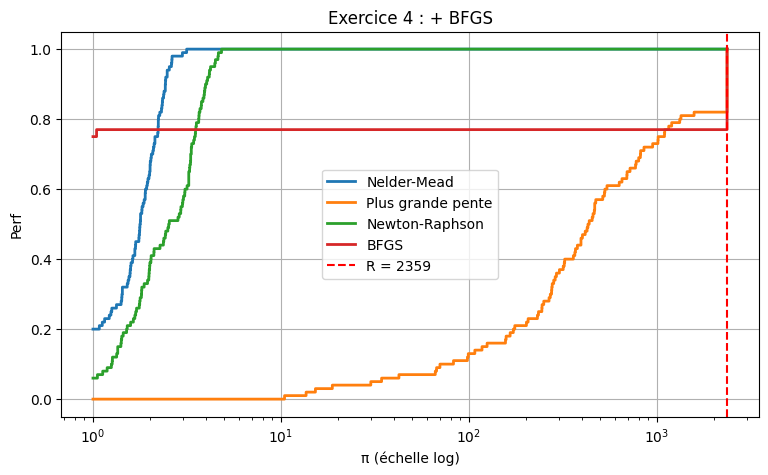


========== EXERCICE 5 ==========

Résumé des performances
----------------------------------------------------------------------
Nelder-Mead          | taux succès = 100.00% | moy = 200.9 | méd = 201.5 | min = 132.0 | max = 277.0
Plus grande pente    | taux succès = 82.00% | moy = 50247.1 | méd = 37971.5 | min = 1645.0 | max = 99387.0
Newton-Raphson       | taux succès = 100.00% | moy = 314.7 | méd = 297.0 | min = 108.0 | max = 577.0
BFGS                 | taux succès = 77.00% | moy = 108.7 | méd = 102.0 | min = 48.0 | max = 216.0
CG                   | taux succès = 96.00% | moy = 156.1 | méd = 156.5 | min = 72.0 | max = 270.0


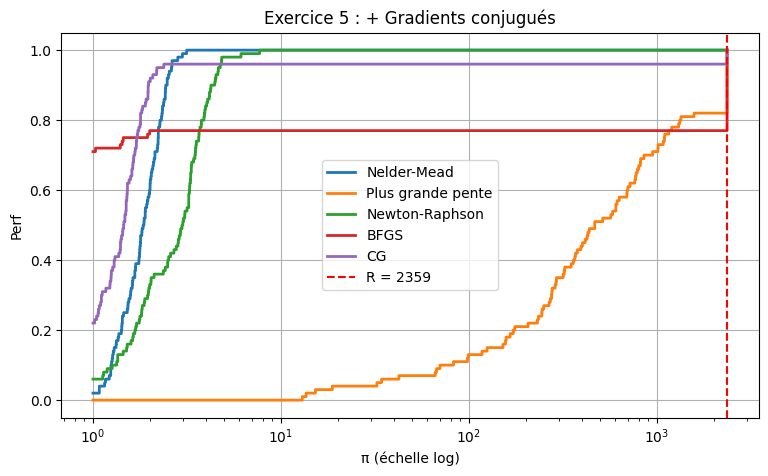

In [6]:
# ============================================================
# 1) Fonction de Rosenbrock
# ============================================================
def rosenbrock(x):
    x1, x2 = x
    return 100.0 * (x2 - x1**2)**2 + (1.0 - x1)**2


# ============================================================
# 2) Compteur d'évaluations de fonction
#    -> très important pour rester fidèle à l'annexe
# ============================================================
class FunctionCounter:
    def __init__(self, f):
        self.f = f
        self.count = 0

    def __call__(self, x):
        self.count += 1
        return self.f(np.asarray(x, dtype=float))


# ============================================================
# 3) Gradient numérique (différences centrées)
# ============================================================
def numerical_gradient(f_counter, x, h=1e-6):
    x = np.asarray(x, dtype=float)
    n = len(x)
    g = np.zeros(n)

    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        g[i] = (f_counter(x + h * e) - f_counter(x - h * e)) / (2.0 * h)

    return g


# ============================================================
# 4) Hessienne numérique (différences centrées)
# ============================================================
def numerical_hessian(f_counter, x, h=1e-4):
    x = np.asarray(x, dtype=float)
    n = len(x)
    H = np.zeros((n, n))

    fx = f_counter(x)

    # Diagonale
    for i in range(n):
        e = np.zeros(n)
        e[i] = 1.0
        H[i, i] = (f_counter(x + h * e) - 2.0 * fx + f_counter(x - h * e)) / (h**2)

    # Hors diagonale
    for i in range(n):
        for j in range(i + 1, n):
            ei = np.zeros(n)
            ej = np.zeros(n)
            ei[i] = 1.0
            ej[j] = 1.0

            H_ij = (
                f_counter(x + h * ei + h * ej)
                - f_counter(x + h * ei - h * ej)
                - f_counter(x - h * ei + h * ej)
                + f_counter(x - h * ei - h * ej)
            ) / (4.0 * h**2)

            H[i, j] = H_ij
            H[j, i] = H_ij

    return H


# ============================================================
# 5) Line search : on optimise le pas alpha
#    phi(alpha) = f(x + alpha d)
# ============================================================
def line_search_exact_1d(f_counter, x, d, alpha_max=2.0, xatol=1e-6, maxiter=80):
    def phi(alpha):
        return f_counter(x + alpha * d)

    res = minimize_scalar(
        phi,
        bounds=(0.0, alpha_max),
        method="bounded",
        options={"xatol": xatol, "maxiter": maxiter}
    )

    return res.x


# ============================================================
# 6) Plus grande pente (à la main)
# ============================================================
def steepest_descent(
    x0,
    f,
    max_iter=5000,
    grad_tol=1e-6,
    step_tol=1e-10,
    dist_tol=1e-2
):
    f_counter = FunctionCounter(f)
    x = np.asarray(x0, dtype=float).copy()
    target = np.array([1.0, 1.0])

    for k in range(max_iter):
        g = numerical_gradient(f_counter, x)

        if np.linalg.norm(g) < grad_tol:
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k,
                "nfev": f_counter.count
            }

        d = -g

        if np.linalg.norm(d) < step_tol:
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k,
                "nfev": f_counter.count
            }

        alpha = line_search_exact_1d(f_counter, x, d, alpha_max=2.0)

        x_new = x + alpha * d

        if np.linalg.norm(x_new - x) < step_tol:
            x = x_new
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k + 1,
                "nfev": f_counter.count
            }

        x = x_new

    success = np.linalg.norm(x - target) < dist_tol
    return {
        "x": x,
        "success": success,
        "nit": max_iter,
        "nfev": f_counter.count
    }


# ============================================================
# 7) Newton-Raphson avec line search (à la main)
# ============================================================
def newton_raphson(
    x0,
    f,
    max_iter=5000,
    grad_tol=1e-6,
    step_tol=1e-10,
    dist_tol=1e-2,
    reg=1e-8
):
    f_counter = FunctionCounter(f)
    x = np.asarray(x0, dtype=float).copy()
    target = np.array([1.0, 1.0])

    for k in range(max_iter):
        g = numerical_gradient(f_counter, x)

        if np.linalg.norm(g) < grad_tol:
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k,
                "nfev": f_counter.count
            }

        H = numerical_hessian(f_counter, x)

        # Régularisation légère pour éviter les problèmes numériques
        H_reg = H + reg * np.eye(len(x))

        try:
            d = -np.linalg.solve(H_reg, g)
        except np.linalg.LinAlgError:
            # Si la Hessienne pose problème, on retombe sur -gradient
            d = -g

        # Sauvegarde : si la direction n'est pas de descente, on prend -gradient
        if np.dot(g, d) >= 0:
            d = -g

        if np.linalg.norm(d) < step_tol:
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k,
                "nfev": f_counter.count
            }

        alpha = line_search_exact_1d(f_counter, x, d, alpha_max=2.0)

        x_new = x + alpha * d

        if np.linalg.norm(x_new - x) < step_tol:
            x = x_new
            success = np.linalg.norm(x - target) < dist_tol
            return {
                "x": x,
                "success": success,
                "nit": k + 1,
                "nfev": f_counter.count
            }

        x = x_new

    success = np.linalg.norm(x - target) < dist_tol
    return {
        "x": x,
        "success": success,
        "nit": max_iter,
        "nfev": f_counter.count
    }


# ============================================================
# 8) Algorithmes SciPy (équivalent à optim() côté Python)
#    Mesure = nombre d'évaluations de fonction
# ============================================================
def run_scipy_method(method_name, x0, f, max_iter=5000, dist_tol=1e-2):
    f_counter = FunctionCounter(f)
    target = np.array([1.0, 1.0])

    if method_name == "Nelder-Mead":
        res = minimize(
            f_counter,
            x0,
            method="Nelder-Mead",
            options={
                "maxiter": max_iter,
                "xatol": 1e-8,
                "fatol": 1e-8,
                "disp": False
            }
        )
    elif method_name in ["BFGS", "CG"]:
        # jac=None -> gradient numérique interne
        res = minimize(
            f_counter,
            x0,
            method=method_name,
            jac=None,
            options={
                "maxiter": max_iter,
                "disp": False
            }
        )
    else:
        raise ValueError(f"Méthode inconnue : {method_name}")

    success = bool(res.success) and (np.linalg.norm(res.x - target) < dist_tol)

    return {
        "x": res.x,
        "success": success,
        "nit": res.nit if hasattr(res, "nit") else None,
        "nfev": f_counter.count
    }


# ============================================================
# 9) Lanceur générique
# ============================================================
def run_algorithm(algo_name, x0, f, max_iter=5000, dist_tol=1e-2):
    if algo_name == "Plus grande pente":
        return steepest_descent(x0, f, max_iter=max_iter, dist_tol=dist_tol)

    elif algo_name == "Newton-Raphson":
        return newton_raphson(x0, f, max_iter=max_iter, dist_tol=dist_tol)

    elif algo_name in ["Nelder-Mead", "BFGS", "CG"]:
        return run_scipy_method(algo_name, x0, f, max_iter=max_iter, dist_tol=dist_tol)

    else:
        raise ValueError(f"Algorithme inconnu : {algo_name}")


# ============================================================
# 10) Exécution sur N problèmes
# ============================================================
def benchmark_algorithms(
    algorithms,
    initial_points,
    f,
    max_iter=5000,
    dist_tol=1e-2
):
    N = len(initial_points)
    tau = {algo: np.full(N, np.inf) for algo in algorithms}
    details = {algo: [] for algo in algorithms}

    for i, x0 in enumerate(initial_points):
        for algo in algorithms:
            res = run_algorithm(algo, x0, f, max_iter=max_iter, dist_tol=dist_tol)
            details[algo].append(res)

            if res["success"]:
                tau[algo][i] = res["nfev"]
            else:
                tau[algo][i] = np.inf

    return tau, details


# ============================================================
# 11) Construction des rho_{p,alpha}
# ============================================================
def build_performance_ratios(tau_dict):
    algos = list(tau_dict.keys())
    tau_matrix = np.vstack([tau_dict[a] for a in algos])   # shape = (m, N)

    # T_p = meilleure performance sur le problème p
    Tp = np.min(tau_matrix, axis=0)

    # Problèmes résolus par au moins un algorithme
    valid = np.isfinite(Tp)

    # On garde uniquement ces problèmes-là
    tau_valid = tau_matrix[:, valid]
    Tp_valid = Tp[valid]

    rho = tau_valid / Tp_valid

    finite_rho = rho[np.isfinite(rho)]
    if finite_rho.size == 0:
        R = 2.0
    else:
        R = np.floor(1.5 * np.max(finite_rho))
        if R <= 1:
            R = 2.0

    rho[~np.isfinite(rho)] = R

    return algos, rho, R, valid.sum()


# ============================================================
# 12) Performance profile
#     P_alpha(pi) = proportion de problèmes tels que rho <= pi
# ============================================================
def performance_profile(rho, pi_values):
    m, Np = rho.shape
    perf = np.zeros((m, len(pi_values)))

    for i in range(m):
        for j, pi in enumerate(pi_values):
            perf[i, j] = np.mean(rho[i, :] <= pi)

    return perf


# ============================================================
# 13) Affichage du performance profile
# ============================================================
def plot_performance_profile(tau_dict, title):
    algos, rho, R, n_valid = build_performance_ratios(tau_dict)

    pi_values = np.logspace(0, np.log10(R + 0.1), 3000)

    perf = performance_profile(rho, pi_values)

    plt.figure(figsize=(9,5))

    for i, algo in enumerate(algos):
       plt.step(pi_values, perf[i], where="post", linewidth=2, label=algo)
    plt.axvline(R, linestyle="--", linewidth=1.5, color="red", label=f"R = {R:.0f}")
    plt.xscale("log")   # ← échelle logarithmique
    plt.xlabel("π (échelle log)")
    plt.ylabel("Perf")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


# ============================================================
# 14) Petit résumé numérique en plus
# ============================================================
def print_summary(tau_dict):
    print("\nRésumé des performances")
    print("-" * 70)

    for algo, values in tau_dict.items():
        success_rate = np.mean(np.isfinite(values))
        finite_vals = values[np.isfinite(values)]

        if len(finite_vals) > 0:
            mean_eval = np.mean(finite_vals)
            median_eval = np.median(finite_vals)
            best_eval = np.min(finite_vals)
            worst_eval = np.max(finite_vals)
        else:
            mean_eval = median_eval = best_eval = worst_eval = np.nan

        print(f"{algo:20s} | taux succès = {success_rate:.2%} | "
              f"moy = {mean_eval:.1f} | méd = {median_eval:.1f} | "
              f"min = {best_eval:.1f} | max = {worst_eval:.1f}")


# ============================================================
# 15) Données expérimentales du prof
# ============================================================
np.random.seed(0)   # pour reproductibilité

N = 100
max_iter = 5000

initial_points = np.random.uniform(-2, 2, size=(N, 2))

# ============================================================
# 16) EXERCICE 2
#     Nelder-Mead vs Plus grande pente
# ============================================================
algos_ex2 = ["Nelder-Mead", "Plus grande pente"]
tau_ex2, details_ex2 = benchmark_algorithms(
    algos_ex2, initial_points, rosenbrock, max_iter=max_iter
)

print("\n========== EXERCICE 2 ==========")
print_summary(tau_ex2)
plot_performance_profile(
    tau_ex2,
    "Exercice 2 : Nelder-Mead vs Plus grande pente"
)

# ============================================================
# 17) EXERCICE 3
#     On ajoute Newton-Raphson
# ============================================================
algos_ex3 = ["Nelder-Mead", "Plus grande pente", "Newton-Raphson"]
tau_ex3, details_ex3 = benchmark_algorithms(
    algos_ex3, initial_points, rosenbrock, max_iter=max_iter
)

print("\n========== EXERCICE 3 ==========")
print_summary(tau_ex3)
plot_performance_profile(
    tau_ex3,
    "Exercice 3 : + Newton-Raphson"
)

# ============================================================
# 18) EXERCICE 4
#     On ajoute BFGS
# ============================================================
algos_ex4 = ["Nelder-Mead", "Plus grande pente", "Newton-Raphson", "BFGS"]
tau_ex4, details_ex4 = benchmark_algorithms(
    algos_ex4, initial_points, rosenbrock, max_iter=max_iter
)

print("\n========== EXERCICE 4 ==========")
print_summary(tau_ex4)
plot_performance_profile(
    tau_ex4,
    "Exercice 4 : + BFGS"
)

# ============================================================
# 19) EXERCICE 5
#     On ajoute CG
# ============================================================
algos_ex5 = ["Nelder-Mead", "Plus grande pente", "Newton-Raphson", "BFGS", "CG"]
tau_ex5, details_ex5 = benchmark_algorithms(
    algos_ex5, initial_points, rosenbrock, max_iter=max_iter
)

print("\n========== EXERCICE 5 ==========")
print_summary(tau_ex5)
plot_performance_profile(
    tau_ex5,
    "Exercice 5 : + Gradients conjugués"
)

Estimateur Newton : 0.8924960552804253
Estimateur optimize : 0.8924965859929258


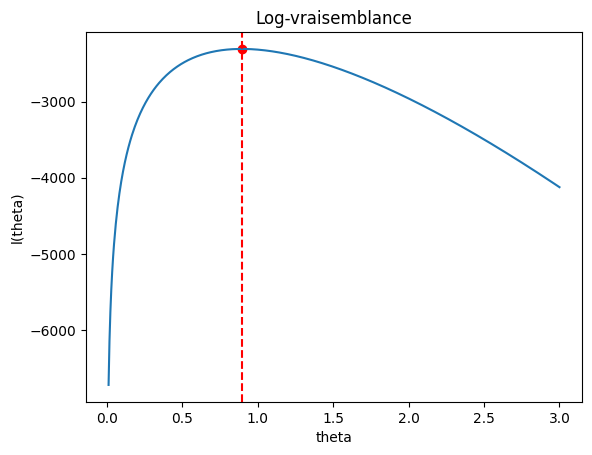

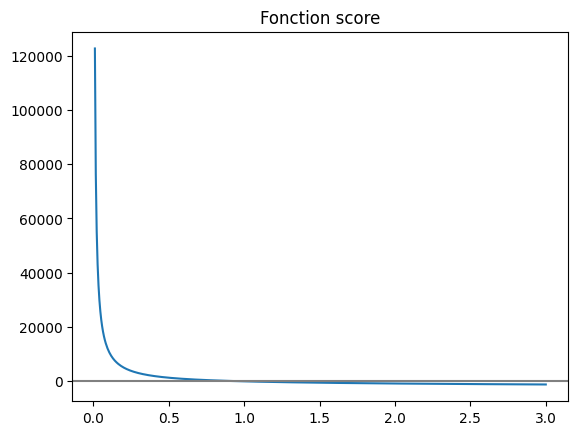

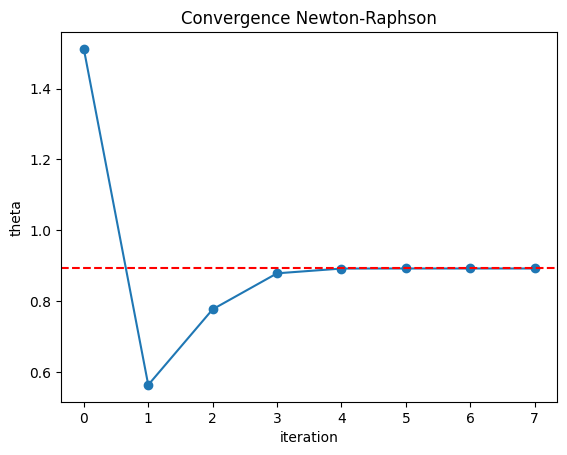

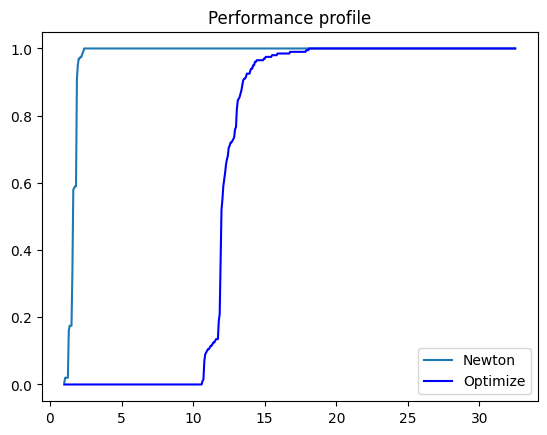

In [7]:
# ==========================================
# Données
# ==========================================

x  = np.array([1,2,3,4,5,6])
fx = np.array([1486,694,195,37,10,1])

n = np.sum(fx)
S = np.sum(x*fx)

theta0 = S/n

# ==========================================
# Score et Hessienne
# ==========================================

def score(theta):
    return -n + S/theta - n*np.exp(-theta)/(1-np.exp(-theta))

def hessian(theta):
    return -S/theta**2 + n*np.exp(-theta)/(1-np.exp(-theta))**2

# ==========================================
# Log-vraisemblance
# ==========================================

def loglik(theta):
    return -n*theta + S*np.log(theta) - np.sum(fx*np.log([factorial(i) for i in x])) - n*np.log(1-np.exp(-theta))

# ==========================================
# Newton-Raphson
# ==========================================

def newton_trace(theta0, tol=1e-8, maxiter=50):

    theta = theta0
    trace = [theta]

    for i in range(maxiter):

        theta_new = theta - score(theta)/hessian(theta)
        trace.append(theta_new)

        if abs(theta_new-theta) < tol:
            break

        theta = theta_new

    return theta_new, np.array(trace)

theta_nr, trace = newton_trace(theta0)

print("Estimateur Newton :", theta_nr)

# ==========================================
# Maximisation directe (équivalent optimize)
# ==========================================

res = minimize_scalar(lambda t: -loglik(t), bounds=(0.5,1.5), method='bounded')
theta_opt = res.x

print("Estimateur optimize :", theta_opt)

# ==========================================
# Courbe log-vraisemblance
# ==========================================

theta_grid = np.linspace(0.01,3,500)
ll_vals = [loglik(t) for t in theta_grid]

plt.figure()
plt.plot(theta_grid,ll_vals)
plt.axvline(theta_opt,color="red",linestyle="--")
plt.scatter(theta_opt,loglik(theta_opt),color="red")
plt.title("Log-vraisemblance")
plt.xlabel("theta")
plt.ylabel("l(theta)")
plt.show()

# ==========================================
# Score
# ==========================================

score_vals = [score(t) for t in theta_grid]

plt.figure()
plt.plot(theta_grid,score_vals)
plt.axhline(0,color="gray")
plt.title("Fonction score")
plt.show()

# ==========================================
# Convergence Newton
# ==========================================

plt.figure()
plt.plot(trace,'o-')
plt.axhline(theta_opt,color="red",linestyle="--")
plt.title("Convergence Newton-Raphson")
plt.xlabel("iteration")
plt.ylabel("theta")
plt.show()

# ==========================================
# Comparaison des temps
# ==========================================

x0 = np.random.uniform(0.5,1.5,200)

dt = np.zeros((200,2))

for i in range(200):

    t0 = time.time()
    newton_trace(x0[i])
    t1 = time.time()
    dt[i,0] = t1-t0

    t0 = time.time()
    minimize_scalar(lambda t: -loglik(t), bounds=(x0[i]-0.8,x0[i]+0.8), method='bounded')
    t1 = time.time()
    dt[i,1] = t1-t0

tau = np.min(dt)

rho = dt/tau

R = 1.5*np.max(rho)

p = np.linspace(1,1.2*R,500)

def pr1(x):
    return np.mean(rho[:,0]<=x)

def pr2(x):
    return np.mean(rho[:,1]<=x)

perf1 = [pr1(v) for v in p]
perf2 = [pr2(v) for v in p]

plt.plot(p,perf1,label="Newton")
plt.plot(p,perf2,label="Optimize",color="blue")
plt.legend()
plt.title("Performance profile")
plt.show()

xmin = 5.6421950015636915

Estimation par Nelder-Mead (énoncé) :
alpha_hat = 4.870150395485001
sigma_hat = 0.9689242673909327
p_hat = 6.380916626168563


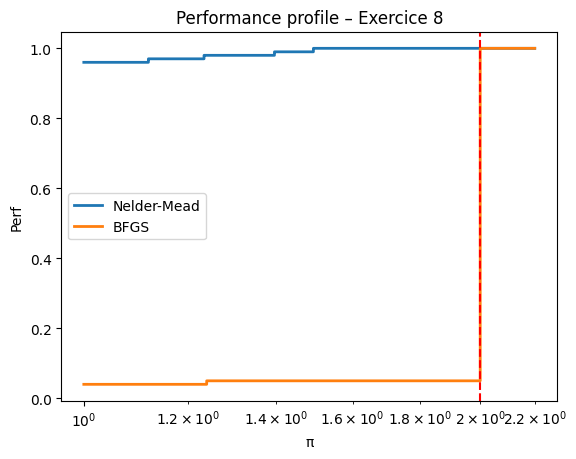

In [20]:
# =====================================================
# 1) Simulation des données
# =====================================================

np.random.seed(123)

n = 5000
alpha_true = 5
sigma_true = 1
p_true = 6

x = np.random.gamma(shape=p_true, scale=sigma_true, size=n) + alpha_true
xmin = np.min(x)

print("xmin =", xmin)

# =====================================================
# 2) Log-vraisemblance reparamétrisée
# =====================================================

def negloglik(theta, x):

    w, u, v = theta

    alpha = xmin - w**2
    sigma = u**2
    p = 2 + v**2

    if sigma <= 0 or p <= 2 or np.any(x <= alpha):
        return np.inf

    n = len(x)

    ll = (
        -n*p*np.log(sigma)
        - n*gammaln(p)
        + (p-1)*np.sum(np.log(x-alpha))
        - np.sum((x-alpha)/sigma)
    )

    return -ll


# =====================================================
# 3) Estimation demandée dans l'énoncé (Nelder–Mead)
# =====================================================

theta0 = np.array([0.01, 2, 1])

res_nm = minimize(
    negloglik,
    theta0,
    args=(x,),
    method="Nelder-Mead"
)

w_hat, u_hat, v_hat = res_nm.x

alpha_hat = xmin - w_hat**2
sigma_hat = u_hat**2
p_hat = 2 + v_hat**2

print("\nEstimation par Nelder-Mead (énoncé) :")
print("alpha_hat =", alpha_hat)
print("sigma_hat =", sigma_hat)
print("p_hat =", p_hat)


# =====================================================
# 4) Paramètres de l'expérience (annexe)
# =====================================================

N = 100
maxit = 5000

taunm = []
taubfgs = []

# =====================================================
# 5) Boucle d'expériences
# =====================================================

for i in range(N):

    theta0 = np.array([
        np.random.uniform(0.001,0.2),
        np.random.uniform(1,3),
        np.random.uniform(0.5,2)
    ])

    # ---------- Nelder-Mead ----------

    t0 = time.perf_counter()

    nm = minimize(
        negloglik,
        theta0,
        args=(x,),
        method="Nelder-Mead",
        options={"maxiter":maxit}
    )

    t1 = time.perf_counter()

    if not nm.success:
        taunm.append(np.inf)
    else:
        taunm.append(t1-t0)

    # ---------- BFGS ----------

    t0 =time.perf_counter()

    bfgs = minimize(
        negloglik,
        theta0,
        args=(x,),
        method="BFGS",
        options={"maxiter":maxit}
    )

    t1 = time.perf_counter()

    if not bfgs.success:
        taubfgs.append(np.inf)
    else:
        taubfgs.append(t1-t0)

taunm = np.array(taunm)
taubfgs = np.array(taubfgs)

# =====================================================
# 6) Performance relative (annexe)
# =====================================================

tp = np.minimum(taunm, taubfgs)

rhonm = taunm/tp
rhobfgs = taubfgs/tp

R = np.floor(
    1.5*np.max(
        np.concatenate([
            rhonm[np.isfinite(rhonm)],
            rhobfgs[np.isfinite(rhobfgs)]
        ])
    )
)

rhonm[np.isinf(rhonm)] = R
rhobfgs[np.isinf(rhobfgs)] = R


# =====================================================
# 7) Fonctions de performance
# =====================================================

def fnm(pi):
    return np.mean(rhonm <= pi)

def fbfgs(pi):
    return np.mean(rhobfgs <= pi)


# =====================================================
# 8) Performance profile
# =====================================================

pi_vals = np.linspace(1, R*1.1, 10000)

ynm = [fnm(p) for p in pi_vals]
ybfgs = [fbfgs(p) for p in pi_vals]

plt.figure()

plt.step(pi_vals, ynm, where="pre", linewidth=2, label="Nelder-Mead")
plt.step(pi_vals, ybfgs, where="pre", linewidth=2, label="BFGS")

plt.axvline(R, color="red", linestyle="--")

plt.xscale("log")

plt.xlabel("π")
plt.ylabel("Perf")

plt.title("Performance profile – Exercice 8")

plt.legend()

plt.show()

In [21]:
##EXo9:

Convergence atteinte à l'itération 8
pi_hat = 0.626821484140


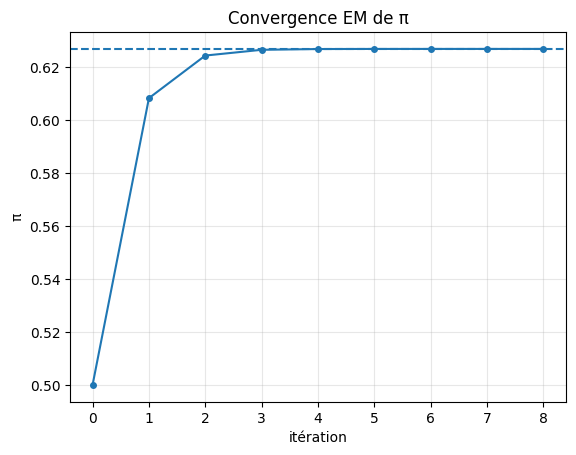

In [22]:
# ==========================================
# Données
# ==========================================
y1, y2, y3, y4 = 125, 18, 20, 34
pi_ = 0.5
eps = 1e-7
maxit = 10000

# Pour tracer / inspecter
pi_hist = [pi_]

# ==========================================
# Algorithme EM
# ==========================================
for i in range(1, maxit + 1):

    # --- E-step ---
    denom = 1/2 + pi_ / 4
    x1_hat = y1 * (1/2) / denom
    x2_hat = y1 * (pi_ / 4) / denom

    x3_hat = y2
    x4_hat = y3
    x5_hat = y4

    # --- M-step ---
    pi_new = (x2_hat + x5_hat) / (x2_hat + x3_hat + x4_hat + x5_hat)

    pi_hist.append(pi_new)

    # critère d'arrêt
    if abs(pi_new - pi_) < eps:
        pi_ = pi_new
        print(f"Convergence atteinte à l'itération {i}")
        break

    pi_ = pi_new

print(f"pi_hat = {pi_:.12f}")

# ==========================================
# Courbe de convergence
# ==========================================
plt.figure()
plt.plot(pi_hist, 'o-', markersize=4)
plt.axhline(pi_, linestyle='--')
plt.xlabel("itération")
plt.ylabel("π")
plt.title("Convergence EM de π")
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
##Exo10

EM convergence : True
EM itérations  : 34
EM theta       : [p, mu1, mu2, sig1, sig2] = [ 0.35425966 -0.01665323  2.89662006  0.67283639  0.91673714]


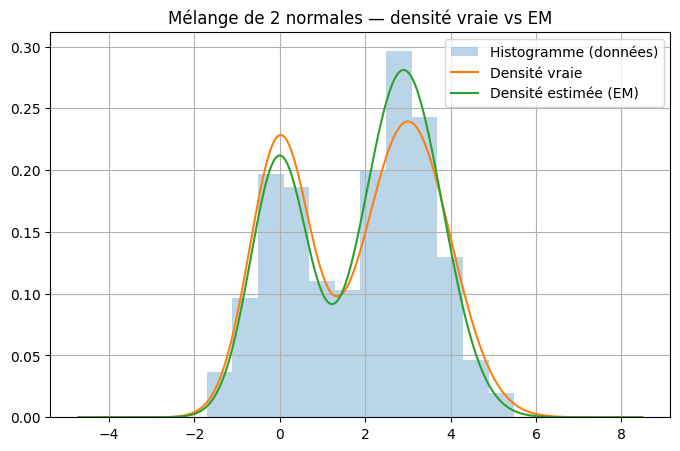

In [28]:
# ============================================================
# 1) Simulation du mélange gaussien
# ============================================================

def sample_gmm_1d(n, p, mu1, mu2, sig1, sig2, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.uniform(size=n) < p
    x = np.empty(n)
    x[z]  = rng.normal(loc=mu1, scale=sig1, size=z.sum())
    x[~z] = rng.normal(loc=mu2, scale=sig2, size=(~z).sum())
    return x

# Paramètres vrais
p_true  = 0.4
mu1_true, mu2_true = 0.0, 3.0
sig1_true = np.sqrt(0.5)
sig2_true = 1.0

n = 500
x = sample_gmm_1d(n, p_true, mu1_true, mu2_true, sig1_true, sig2_true, seed=0)

# ============================================================
# 2) EM pour mélange de 2 normales (1D)
# ============================================================

def em_gmm_1d(x, p0, mu10, mu20, var10, var20, eps=1e-4, max_iter=1000):
    # Paramètres courants (on stocke sigma, pas variance)
    p = float(p0)
    mu1, mu2 = float(mu10), float(mu20)
    sig1, sig2 = np.sqrt(float(var10)), np.sqrt(float(var20))

    history = []

    for k in range(max_iter):
        # ----- E-step : responsabilités gamma_i = P(Z=1|x_i)
        f1 = norm.pdf(x, loc=mu1, scale=sig1)
        f2 = norm.pdf(x, loc=mu2, scale=sig2)

        denom = p * f1 + (1 - p) * f2
        # sécurité numérique
        denom = np.maximum(denom, 1e-300)

        gamma = (p * f1) / denom  # taille n

        # ----- M-step : mises à jour fermées
        Nk1 = gamma.sum()
        Nk2 = (1 - gamma).sum()

        p_new = Nk1 / len(x)
        mu1_new = (gamma @ x) / Nk1
        mu2_new = ((1 - gamma) @ x) / Nk2

        var1_new = (gamma @ (x - mu1_new)**2) / Nk1
        var2_new = ((1 - gamma) @ (x - mu2_new)**2) / Nk2

        sig1_new = np.sqrt(max(var1_new, 1e-12))
        sig2_new = np.sqrt(max(var2_new, 1e-12))

        theta = np.array([p, mu1, mu2, sig1, sig2])
        theta_new = np.array([p_new, mu1_new, mu2_new, sig1_new, sig2_new])

        history.append(theta_new.copy())

        # critère de convergence (distance euclidienne)
        if np.linalg.norm(theta_new - theta) < eps:
            return theta_new, True, k+1, np.array(history)

        p, mu1, mu2, sig1, sig2 = p_new, mu1_new, mu2_new, sig1_new, sig2_new

    return np.array([p, mu1, mu2, sig1, sig2]), False, max_iter, np.array(history)

# Init demandée
theta_em, conv_em, it_em, hist_em = em_gmm_1d(
    x,
    p0=0.2,
    mu10=1.0,
    mu20=2.0,
    var10=1.0,
    var20=0.5,
    eps=1e-4,
    max_iter=1000
)

print("EM convergence :", conv_em)
print("EM itérations  :", it_em)
print("EM theta       : [p, mu1, mu2, sig1, sig2] =", theta_em)

# ============================================================
# 3) Densité vraie vs densité estimée (même graphique)
# ============================================================

def mix_pdf(xgrid, p, mu1, mu2, sig1, sig2):
    return p*norm.pdf(xgrid, mu1, sig1) + (1-p)*norm.pdf(xgrid, mu2, sig2)

xgrid = np.linspace(x.min()-3, x.max()+3, 400)

pdf_true = mix_pdf(xgrid, p_true, mu1_true, mu2_true, sig1_true, sig2_true)
pdf_em   = mix_pdf(xgrid, *theta_em)

plt.figure(figsize=(8,5))
plt.hist(x, bins=12, density=True, alpha=0.3, label="Histogramme (données)")
plt.plot(xgrid, pdf_true, label="Densité vraie")
plt.plot(xgrid, pdf_em, label="Densité estimée (EM)")
plt.title("Mélange de 2 normales — densité vraie vs EM")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# ======================================================
# 4) Maximisation directe
# ======================================================

def sigmoid(a):
    return 1/(1+np.exp(-a))

def negloglik(par,x):

    mu1,mu2,a,b1,b2 = par

    p = sigmoid(a)
    s1 = np.exp(b1)
    s2 = np.exp(b2)

    l1 = np.log(p)+norm.logpdf(x,mu1,s1)
    l2 = np.log(1-p)+norm.logpdf(x,mu2,s2)

    m = np.maximum(l1,l2)

    ll = np.sum(m+np.log(np.exp(l1-m)+np.exp(l2-m)))

    return -ll


p0 = 0.2
mu10 = 1
mu20 = 2
s10 = np.sqrt(1)
s20 = np.sqrt(0.5)

par0 = [
    mu10,
    mu20,
    np.log(p0/(1-p0)),
    np.log(s10),
    np.log(s20)
]

methods = ["Nelder-Mead","BFGS","CG"]

results = {}

for m in methods:

    res = minimize(negloglik,par0,args=(x,),method=m)

    mu1,mu2,a,b1,b2 = res.x

    p = sigmoid(a)
    s1 = np.exp(b1)
    s2 = np.exp(b2)

    results[m] = np.array([p,mu1,mu2,s1,s2])

print("Résultats optim :",results)

Résultats optim : {'Nelder-Mead': array([ 0.35418711, -0.01688992,  2.89645793,  0.6726614 ,  0.91688422]), 'BFGS': array([ 0.35419387, -0.01685987,  2.89643657,  0.67269394,  0.91688437]), 'CG': array([ 0.35419385, -0.01685989,  2.89643655,  0.67269392,  0.91688438])}


/home/bocoum/E21B622L/Python/env/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


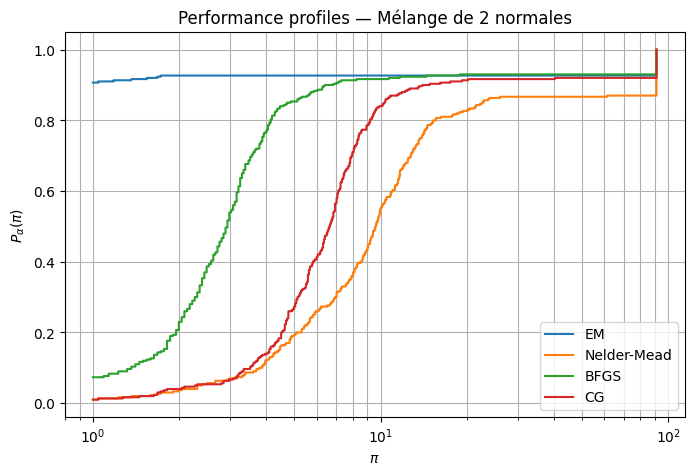

In [34]:
#============================================================
# 0) densité mélange + log-vraisemblance
# ============================================================

def mix_pdf(x, p, mu1, mu2, sig1, sig2):
    return p * norm.pdf(x, mu1, sig1) + (1 - p) * norm.pdf(x, mu2, sig2)

def neg_loglik_gmm_params(params, x):
    """
    Négative log-vraisemblance avec paramètres 'directs'
    params = (p, mu1, mu2, sig1, sig2)
    """
    p, mu1, mu2, sig1, sig2 = params
    # contraintes
    if not (0 < p < 1) or sig1 <= 0 or sig2 <= 0:
        return np.inf
    f = mix_pdf(x, p, mu1, mu2, sig1, sig2)
    f = np.maximum(f, 1e-300)
    return -np.sum(np.log(f))

def canonicalize(params):
    """
    Pour éviter le 'label switching' (composantes permutées),
    on impose mu1 <= mu2 en échangeant les composantes si besoin.
    """
    p, mu1, mu2, sig1, sig2 = params
    if mu1 <= mu2:
        return (p, mu1, mu2, sig1, sig2)
    # swap composantes 1 et 2
    return (1 - p, mu2, mu1, sig2, sig1)

# ============================================================
# 1) SIMULATION DONNEES (fixe) : on compare les algos sur le même échantillon
# ============================================================

def sample_gmm_1d(n, p, mu1, mu2, sig1, sig2, seed=0):
    rng = np.random.default_rng(seed)
    z = rng.uniform(size=n) < p
    x = np.empty(n)
    x[z] = rng.normal(mu1, sig1, size=z.sum())
    x[~z] = rng.normal(mu2, sig2, size=(~z).sum())
    return x

# Paramètres vrais (énoncé)
p_true = 0.4
mu1_true, mu2_true = 0.0, 3.0
sig1_true = np.sqrt(0.5)
sig2_true = 1.0

n = 50
x = sample_gmm_1d(n, p_true, mu1_true, mu2_true, sig1_true, sig2_true, seed=0)

# ============================================================
# 2) EM (convergence : norme euclidienne des paramètres successifs < eps)
# ============================================================

def em_gmm_1d(x, p0, mu10, mu20, var10, var20, eps=1e-4, max_iter=1000):
    # on stocke sigmas
    p = float(p0)
    mu1, mu2 = float(mu10), float(mu20)
    sig1, sig2 = np.sqrt(float(var10)), np.sqrt(float(var20))

    for k in range(max_iter):
        # E-step : responsabilités
        f1 = norm.pdf(x, mu1, sig1)
        f2 = norm.pdf(x, mu2, sig2)
        denom = p * f1 + (1 - p) * f2
        denom = np.maximum(denom, 1e-300)
        gamma = (p * f1) / denom

        # M-step : mises à jour fermées
        Nk1 = gamma.sum()
        Nk2 = (1 - gamma).sum()

        p_new = Nk1 / len(x)
        mu1_new = (gamma @ x) / Nk1
        mu2_new = ((1 - gamma) @ x) / Nk2

        var1_new = (gamma @ (x - mu1_new) ** 2) / Nk1
        var2_new = ((1 - gamma) @ (x - mu2_new) ** 2) / Nk2

        sig1_new = np.sqrt(max(var1_new, 1e-12))
        sig2_new = np.sqrt(max(var2_new, 1e-12))

        theta = np.array([p, mu1, mu2, sig1, sig2])
        theta_new = np.array([p_new, mu1_new, mu2_new, sig1_new, sig2_new])

        # critère demandé
        if np.linalg.norm(theta_new - theta) < eps:
            params = canonicalize((p_new, mu1_new, mu2_new, sig1_new, sig2_new))
            return params, True, k + 1

        p, mu1, mu2, sig1, sig2 = p_new, mu1_new, mu2_new, sig1_new, sig2_new

    params = canonicalize((p, mu1, mu2, sig1, sig2))
    return params, False, max_iter

# ============================================================
# 3) "optim()" version SciPy : NM / BFGS / CG en minimisant -loglik
#    Reparamétrisation sans contraintes :
#      p = sigmoid(a), sig1 = exp(b), sig2 = exp(c)
# ============================================================

def sigmoid(t):
    return 1 / (1 + np.exp(-t))

def unpack_theta(theta):
    # theta = (a, mu1, mu2, b, c)
    a, mu1, mu2, b, c = theta
    p = sigmoid(a)
    sig1 = np.exp(b)
    sig2 = np.exp(c)
    return canonicalize((p, mu1, mu2, sig1, sig2))

def neg_loglik_theta(theta, x):
    p, mu1, mu2, sig1, sig2 = unpack_theta(theta)
    return neg_loglik_gmm_params((p, mu1, mu2, sig1, sig2), x)

def pack_init(p0, mu10, mu20, var10, var20):
    # on transforme p0 -> a0, sigma -> log(sigma)
    p0 = np.clip(p0, 1e-6, 1 - 1e-6)
    a0 = np.log(p0 / (1 - p0))
    b0 = np.log(np.sqrt(var10))
    c0 = np.log(np.sqrt(var20))
    return np.array([a0, mu10, mu20, b0, c0], dtype=float)

def run_minimize(method, theta0, x, max_iter=5000):
    start = time.perf_counter()
    res = minimize(
        neg_loglik_theta,
        theta0,
        args=(x,),
        method=method,
        options={"maxiter": max_iter, "disp": False}
    )
    elapsed = time.perf_counter() - start
    params = unpack_theta(res.x)
    return {
        "params": params,
        "success": bool(res.success) and np.isfinite(res.fun),
        "nit": getattr(res, "nit", None),
        "nfev": getattr(res, "nfev", None),
        "time": elapsed,
        "obj": res.fun
    }

# ============================================================
# 4) METHODOLOGIE ANNEXE : problèmes = points init
#    tau_{p,algo} = temps si "résout", sinon +inf
#    Critère "résout" = convergence ET obj proche du meilleur (tol)
# ============================================================

N_PROBLEMS = 300         # nombre de points init (problèmes)
MAX_ITER = 5000
EPS_EM = 1e-4             # critère EM demandé
OBJ_TOL = 1e-3            # tolérance relative sur -loglik vs meilleur (qualité)

algos = ["EM", "Nelder-Mead", "BFGS", "CG"]

# Génération de points init autour de valeurs raisonnables
rng = np.random.default_rng(0)
p0_list   = rng.uniform(0.05, 0.95, size=N_PROBLEMS)
mu10_list = rng.uniform(-2.0,  4.0, size=N_PROBLEMS)
mu20_list = rng.uniform(-2.0,  6.0, size=N_PROBLEMS)
v10_list  = rng.uniform(0.2,   3.0, size=N_PROBLEMS)   # variances
v20_list  = rng.uniform(0.2,   3.0, size=N_PROBLEMS)

tau = {a: np.zeros(N_PROBLEMS) for a in algos}
obj = {a: np.full(N_PROBLEMS, np.inf) for a in algos}  # -loglik finale

for i in range(N_PROBLEMS):
    p0, mu10, mu20, v10, v20 = p0_list[i], mu10_list[i], mu20_list[i], v10_list[i], v20_list[i]

    # ----- EM
    start = time.perf_counter()
    params_em, ok_em, it_em = em_gmm_1d(x, p0, mu10, mu20, v10, v20, eps=EPS_EM, max_iter=1000)
    t_em = time.perf_counter() - start
    if ok_em:
        obj_em = neg_loglik_gmm_params(params_em, x)
        tau["EM"][i] = t_em
        obj["EM"][i] = obj_em
    else:
        tau["EM"][i] = np.inf

    # init commune pour minimize
    theta0 = pack_init(p0, mu10, mu20, v10, v20)

    # ----- Nelder-Mead / BFGS / CG
    for m in ["Nelder-Mead", "BFGS", "CG"]:
        out = run_minimize(m, theta0, x, max_iter=MAX_ITER)
        if out["success"]:
            tau[m][i] = out["time"]
            obj[m][i] = out["obj"]
        else:
            tau[m][i] = np.inf

    # --------------------------------------------------------
    # Critère "qualité" annexe : un algo "résout" si:
    # - il converge (temps fini)
    # - et son objectif est proche du meilleur objectif obtenu
    #   sur ce problème (point init)
    # --------------------------------------------------------
    best_obj = np.min([obj[a][i] for a in algos])  # meilleur -loglik trouvé
    for a in algos:
        if np.isfinite(tau[a][i]) and np.isfinite(obj[a][i]):
            # tolérance relative (si best_obj > 0)
            if obj[a][i] <= best_obj * (1 + OBJ_TOL) + 1e-12:
                pass  # garde le temps
            else:
                tau[a][i] = np.inf  # considéré comme "non résolu"
        else:
            tau[a][i] = np.inf

# ============================================================
# 5) PROFILS DE PERFORMANCE (Dolan–Moré)
# ============================================================

# Tp = meilleur temps pour chaque problème
Tp = np.array([min(tau[a][i] for a in algos) for i in range(N_PROBLEMS)])

# rho_{p,a}
rho = {a: np.zeros(N_PROBLEMS) for a in algos}
for i in range(N_PROBLEMS):
    for a in algos:
        if np.isfinite(tau[a][i]) and np.isfinite(Tp[i]):
            rho[a][i] = tau[a][i] / Tp[i]
        else:
            rho[a][i] = np.inf

# Choix de R comme dans l'annexe (si besoin)
finite_rhos = np.concatenate([rho[a][np.isfinite(rho[a])] for a in algos])
R = int(np.floor(1.5 * np.max(finite_rhos))) if finite_rhos.size > 0 else 1000

for a in algos:
    rho[a][~np.isfinite(rho[a])] = R

# Grille pi et P_a(pi)
pi_values = np.linspace(1,R, 2000)  # zoom comme ton prof (1 à 25)
P = {a: np.array([np.mean(rho[a] <= pi) for pi in pi_values]) for a in algos}

# ============================================================
# ============================================================

plt.figure(figsize=(8,5))

for a in algos:
    plt.step(pi_values, P[a], where="post", label=a)

plt.xscale("log")   # echelle logarithmique

plt.xlabel(r"$\pi$")
plt.ylabel(r"$P_\alpha(\pi)$")
plt.title("Performance profiles — Mélange de 2 normales")
plt.grid(True, which="both")
plt.legend()
plt.show()


In [ ]:
### Exercicie 11:


Estimation Gauss-Newton
theta1 = 44.40167323454141
theta2 = 242.35505722693756

Estimation Levenberg-Marquardt
theta1 = 44.40167156439842
theta2 = 242.35501968881644


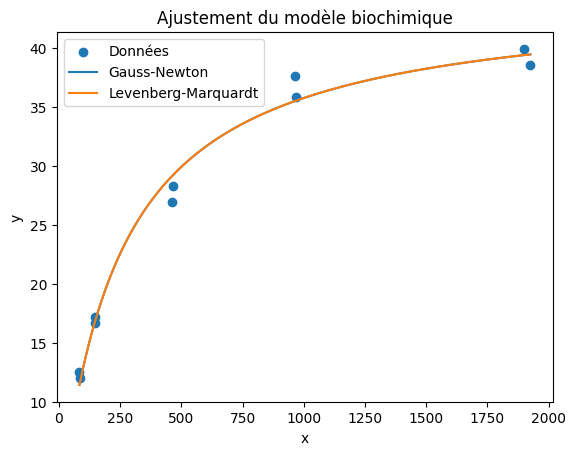

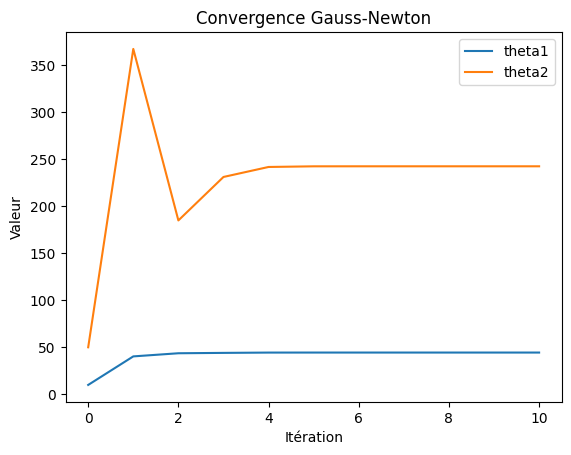

In [43]:
# =======================================================
# 1) Données de l'énoncé
# ============================================================

x = np.array([84.6, 83.9, 148.2, 147.8, 463.9,
              463.8, 964.1, 967.6, 1925.0, 1900.0])

y = np.array([12, 12.5, 17.2, 16.7, 28.3,
              26.9, 37.6, 35.8, 38.5, 39.9])


# ============================================================
# 2) Modèle non linéaire
# y = θ1 x / (θ2 + x)
# ============================================================

def model(x, theta):
    theta1, theta2 = theta
    return theta1 * x / (theta2 + x)


# ============================================================
# 3) Résidus (moindres carrés)
# ============================================================

def residuals(theta, x, y):
    return y - model(x, theta)


# ============================================================
# 4) Jacobienne (dérivées partielles)
# ============================================================

def jacobian(theta, x):

    theta1, theta2 = theta

    J = np.zeros((len(x), 2))

    J[:,0] = -x/(theta2 + x)
    J[:,1] = theta1*x/(theta2 + x)**2

    return J


# ============================================================
# 5) Algorithme Gauss-Newton
# ============================================================

def gauss_newton(x, y, theta0, max_iter=100, tol=1e-6):

    theta = np.array(theta0, dtype=float)

    history = [theta.copy()]

    for k in range(max_iter):

        r = residuals(theta, x, y)
        J = jacobian(theta, x)

        # mise à jour Gauss-Newton
        delta = np.linalg.inv(J.T @ J) @ J.T @ r

        theta_new = theta - delta

        history.append(theta_new.copy())

        if np.linalg.norm(theta_new - theta) < tol:
            break

        theta = theta_new

    return theta, np.array(history)


# ============================================================
# 6) Estimation Gauss-Newton
# ============================================================

theta0 = [10, 50]

theta_gn, hist_gn = gauss_newton(x, y, theta0)

print("Estimation Gauss-Newton")
print("theta1 =", theta_gn[0])
print("theta2 =", theta_gn[1])


# ============================================================
# 7) Levenberg-Marquardt
# ============================================================

res_lm = least_squares(
    residuals,
    theta0,
    args=(x,y),
    method="lm"
)

theta_lm = res_lm.x

print("\nEstimation Levenberg-Marquardt")
print("theta1 =", theta_lm[0])
print("theta2 =", theta_lm[1])


# ============================================================
# 8) Visualisation
# ============================================================

xx = np.linspace(min(x), max(x), 500)

plt.scatter(x, y, label="Données")

plt.plot(xx,
         model(xx, theta_gn),
         label="Gauss-Newton")

plt.plot(xx,
         model(xx, theta_lm),
         label="Levenberg-Marquardt")

plt.xlabel("x")
plt.ylabel("y")

plt.title("Ajustement du modèle biochimique")

plt.legend()
plt.show()


# ============================================================
# 9) Convergence Gauss-Newton
# ============================================================

plt.plot(hist_gn[:,0], label="theta1")
plt.plot(hist_gn[:,1], label="theta2")

plt.xlabel("Itération")
plt.ylabel("Valeur")

plt.title("Convergence Gauss-Newton")

plt.legend()

plt.show()

In [44]:
############Exercice12

Estimation BFGS : [16.47294993 -0.15761557 -0.14940709]
Estimation Nelder-Mead : [16.47283636 -0.15761549 -0.14940558]


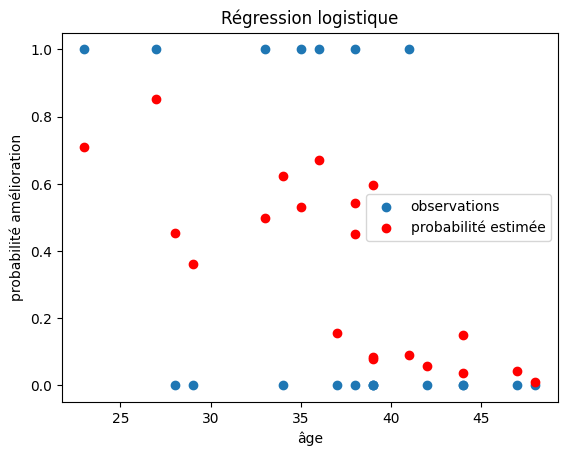

In [46]:
# ============================================================
# 1) Données de l'essai clinique
# ============================================================

y = np.array([
1,1,1,1,1,1,1,
0,0,0,0,0,0,0,0,0,0,0,0,0
])

age = np.array([
27,35,33,38,23,41,36,
34,38,39,37,28,42,44,48,29,39,39,44,47
])

poids = np.array([
70,72.5,75.5,69,80,82.5,67.5,
71,71.5,85,82.5,82,84.5,75.5,90,83.5,66.5,85.5,85.5,81.5
])

n = len(y)

# matrice des variables explicatives (avec constante)
X = np.column_stack((np.ones(n), age, poids))


# ============================================================
# 2) Fonction logistique
# ============================================================

def logistic(z):
    return 1 / (1 + np.exp(-z))


# ============================================================
# 3) Log-vraisemblance
# ============================================================

def neg_loglik(beta):

    z = X @ beta
    p = logistic(z)

    p = np.clip(p,1e-10,1-1e-10)

    ll = np.sum(y*np.log(p) + (1-y)*np.log(1-p))

    return -ll


# ============================================================
# 4) Optimisation
# ============================================================

beta0 = np.zeros(3)

res_bfgs = minimize(
    neg_loglik,
    beta0,
    method="BFGS"
)

res_nm = minimize(
    neg_loglik,
    beta0,
    method="Nelder-Mead"
)

beta_bfgs = res_bfgs.x
beta_nm = res_nm.x

print("Estimation BFGS :",beta_bfgs)
print("Estimation Nelder-Mead :",beta_nm)


# ============================================================
# 5) Probabilités estimées
# ============================================================

p_est = logistic(X @ beta_bfgs)


# ============================================================
# 6) Visualisation
# ============================================================

plt.scatter(age, y, label="observations")

plt.scatter(age, p_est, color="red", label="probabilité estimée")

plt.xlabel("âge")
plt.ylabel("probabilité amélioration")

plt.title("Régression logistique")

plt.legend()

plt.show()
